Neural OT learning OT plan (stochastic neural network)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython.display import clear_output

device = "cuda" if torch.cuda.is_available() else "cpu"


ModuleNotFoundError: No module named 'numpy'

In [ ]:
# source distribution μ
def sample_mu(batch_size, device="cpu"):
    x = 2 * torch.rand(batch_size, 1, device=device) - 1  # [-1,1]
    y = torch.zeros(batch_size, 1, device=device)         # y = 0
    return torch.cat([x, y], dim=1)


# target distribution ν
def sample_nu(batch_size, device="cpu"):
    x = torch.zeros(batch_size, 1, device=device)         # y = 0
    y = 2 * torch.rand(batch_size, 1, device=device) - 1  # [-1,1]
    return torch.cat([x, y], dim=1)

In [ ]:
def sample_nu(batch_size, device="cpu"):
    x = 2 * torch.rand(batch_size, 1, device=device) - 1  # [-1,1]
    y = torch.ones(batch_size, 1, device=device)         # y = 0
    return torch.cat([x, y], dim=1)

In [ ]:
def sample_nu(batch_size, device="cpu"):
    x = 2 * torch.rand(batch_size, 1, device=device) - 1  # [-1,1]

    # choose line: +1 or -1 with equal probability
    sign = torch.randint(0, 2, (batch_size, 1), device=device) * 2 - 1
    y = sign.float()  # either +1 or -1

    return torch.cat([x, y], dim=1)

In [ ]:
def sample_nu(batch_size, device="cpu", n_grid=5):
    grid = torch.linspace(-1, 1, 2*n_grid-1, device=device)  # grid points
    idx = 2*torch.randint(1, n_grid, (batch_size,), device=device)-1

    x = grid[idx].unsqueeze(1)
    y = 2 * torch.rand(batch_size, 1, device=device) - 1

    return torch.cat([x, y], dim=1)

In [ ]:
def sample_mu(batch_size, device="cpu", n_grid=5):
    grid = torch.linspace(-1, 1, 2*n_grid-1, device=device)  # grid points
    idx = 2*torch.randint(1, n_grid, (batch_size,), device=device)-1

    y = grid[idx].unsqueeze(1)
    x = 2 * torch.rand(batch_size, 1, device=device) - 1

    return torch.cat([x, y], dim=1)

In [ ]:
def sample_nu(batch_size, device="cpu"):
    theta = torch.rand(batch_size, 1, device=device) *2*torch.pi
    x = torch.cos(theta)
    y = torch.sin(theta)
    return torch.cat([x,y], dim=1)

In [ ]:
mu = sample_mu(1000)
nu = sample_nu(1000)

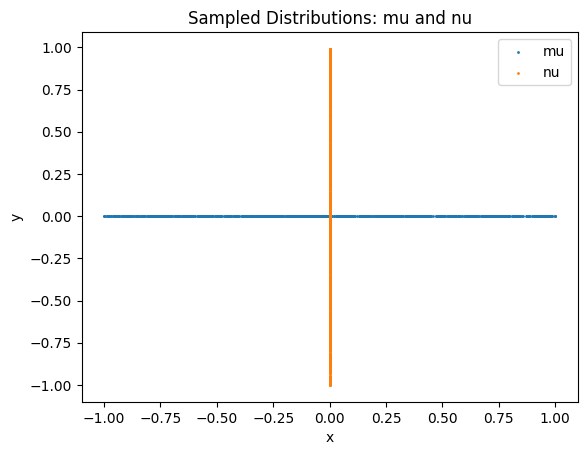

In [ ]:
plt.figure()
plt.scatter(mu[:,0].numpy(), mu[:,1].numpy(), s=1, label="mu")
plt.scatter(nu[:,0].numpy(), nu[:,1].numpy(), s=1, label="nu")
plt.legend()
plt.title("Sampled Distributions: mu and nu")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [ ]:
class Transport(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        z = torch.randn(x.shape[0], 1, device=x.device)
        # z = 2 * torch.rand(x.shape[0], 1, device=x.device) - 1
        return self.net(torch.cat([x, z], dim=1))


class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
def cost(x, y):
    return ((x - y) ** 2).sum(dim=1, keepdim=True)/2

In [ ]:
def show_mapping(T,f,sample_mu,sample_nu, contour = False):
    x = sample_mu(1000).to(device)

    outputs = []
    for _ in range(5):
        outputs.append(T(x).detach().cpu())

    outputs = torch.cat(outputs, dim=0)
    x = x.cpu()
    y = sample_nu(1000).cpu()

    plt.figure()

    if contour:
        x_min, x_max = -2.0, 2.0
        y_min, y_max = -2.0, 2.0
        n = 300  # 해상도

        xs = np.linspace(x_min, x_max, n)
        ys = np.linspace(y_min, y_max, n)
        xx, yy = np.meshgrid(xs, ys)

        grid = np.stack([xx.ravel(), yy.ravel()], axis=1)
        grid_torch = torch.tensor(grid, dtype=torch.float32).to(device)

        with torch.no_grad():
            zz = f(grid_torch).cpu().numpy()
        zz = zz.reshape(n, n)
        plt.contour(xx, yy, zz, levels=20)

    plt.scatter(x[:,0], x[:,1], label="mu", s=1, alpha=0.5)
    plt.scatter(y[:,0], y[:,1], label="nu", s=1, alpha=0.5)
    plt.scatter(outputs[:,0], outputs[:,1], label="T(x,z)", s=1, alpha=0.5)
    plt.axis('equal')
    plt.legend()
    plt.show()

In [ ]:
T = Transport().to(device)
f = Critic().to(device)

step 200000, loss 0.3294


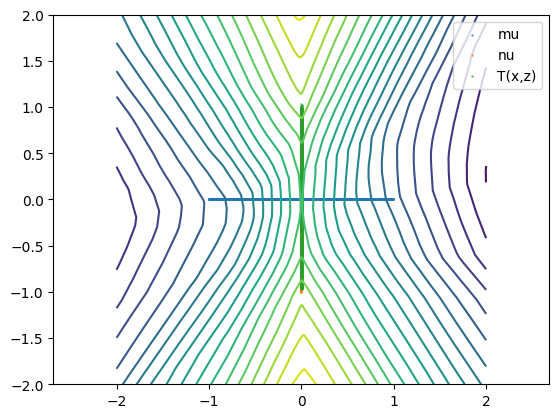

In [ ]:
lr_T = 1e-3
lr_f = 1e-3

batchsize_x = 1024
batchsize_y = 1024
for step in range(200000):
    x = sample_mu(batchsize_x).to(device)
    y = sample_nu(batchsize_y).to(device)

    T_old = [p.clone() for p in T.parameters()]
    f_old = [p.clone() for p in f.parameters()]

    # -------- critic update (maximize) --------
    Tx = T(x)
    loss = cost(x, Tx).mean() - f(Tx).mean() + f(y).mean()
    T_gradient = torch.autograd.grad(loss, T.parameters(), create_graph=True)
    f_gradient = torch.autograd.grad(loss, f.parameters())

    with torch.no_grad():
        for p, g in zip(T.parameters(), T_gradient):
            p -= lr_T * g
        for p, g in zip(f.parameters(), f_gradient):
            p += lr_f * g
    Tx2 = T(x)
    loss2 = cost(x, Tx2).mean() - f(Tx2).mean() + f(y).mean()
    T_grad_true = torch.autograd.grad(loss2, T.parameters(), create_graph=True)
    f_grad_true = torch.autograd.grad(loss2, f.parameters())

    # ----- restore parameters -----
    with torch.no_grad():
        for p, p_old in zip(T.parameters(), T_old):
            p.copy_(p_old)
        for p, p_old in zip(f.parameters(), f_old):
            p.copy_(p_old)

    with torch.no_grad():
        for p, g in zip(T.parameters(), T_grad_true):
            p -= lr_T * g
        for p, g in zip(f.parameters(), f_grad_true):
            p += lr_f * g

    if (step+1) % 500 == 0:
        clear_output(wait=True)
        print(f"step {step+1}, loss {loss.item():.4f}")
        show_mapping(T, f,sample_mu,sample_nu, contour = True)

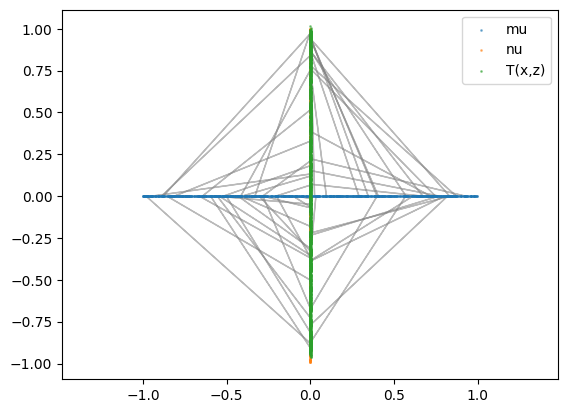

In [ ]:
n_eval = 1000
x = sample_mu(n_eval).to(device)
option = True
outputs = []
for _ in range(2):
    outputs.append(T(x).detach().cpu())

outputs = torch.cat(outputs, dim=0)
x = x.cpu()
y = sample_nu(1000).cpu()

if (option == True):
    for i in range(50):
        plt.arrow(x[i,0], x[i,1],
              outputs[i,0]-x[i,0],
              outputs[i,1]-x[i,1],
              color='gray', alpha=0.5, head_width=0, length_includes_head=True)
    '''
    for i in range(50):
        plt.arrow(x[i,0], x[i,1],
              outputs[i+n_eval,0]-x[i,0],
              outputs[i+n_eval,1]-x[i,1],
              color='gray', alpha=0.5, head_width=0, length_includes_head=True)
    '''

plt.scatter(x[:,0], x[:,1], label="mu", s=1, alpha=0.5)
plt.scatter(y[:,0], y[:,1], label="nu", s=1, alpha=0.5)
plt.scatter(outputs[:,0], outputs[:,1], label="T(x,z)", s=1, alpha=0.5)
plt.axis('equal')
plt.legend()
# plt.title("Minimal NOT (stochastic, GDmax)")
plt.show()

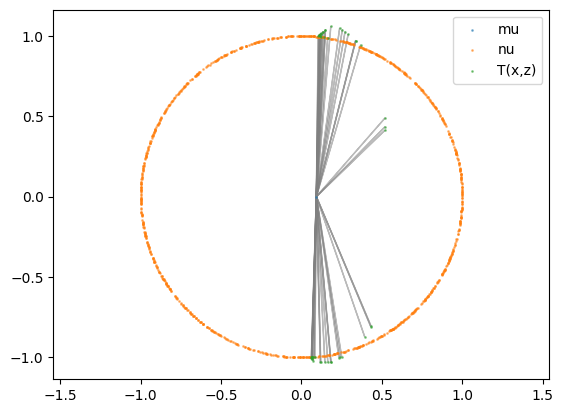

In [ ]:
x = sample_mu(1).to(device)
outputs = []
for _ in range(50):
    outputs.append(T(x).detach().cpu())
outputs = torch.cat(outputs, dim=0)
x = x.cpu()
if (option == True):
    for i in range(50):
        plt.arrow(x[0,0], x[0,1],
              outputs[i,0]-x[0,0],
              outputs[i,1]-x[0,1],
              color='gray', alpha=0.5, head_width=0, length_includes_head=True)
plt.scatter(x[:,0], x[:,1], label="mu", s=1, alpha=0.5)
plt.scatter(y[:,0], y[:,1], label="nu", s=1, alpha=0.5)
plt.scatter(outputs[:,0], outputs[:,1], label="T(x,z)", s=1, alpha=0.5)
plt.axis('equal')
plt.legend()
# plt.title("Minimal NOT (stochastic, GDmax)")
plt.show()


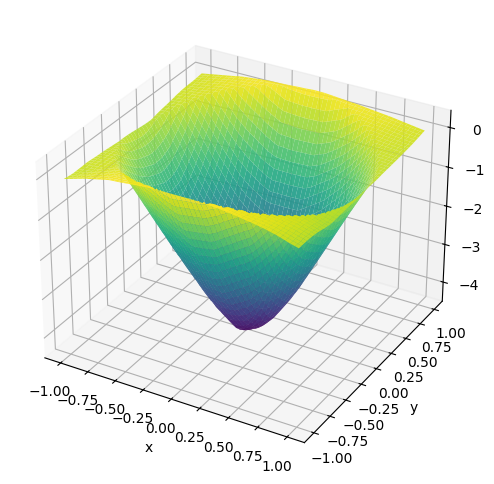

In [ ]:
# plot 범위
x_min, x_max = -1.0, 1.0
y_min, y_max = -1.0, 1.0

resolution = 200  # 클수록 부드러움
x = np.linspace(x_min, x_max, resolution)
y = np.linspace(y_min, y_max, resolution)
X, Y = np.meshgrid(x, y)

# (N^2, 2) 형태로 변환
XY = np.stack([X.ravel(), Y.ravel()], axis=1)
XY_torch = torch.tensor(XY, dtype=torch.float32, device = device)

with torch.no_grad():
    Z = f(XY_torch).cpu().numpy()

Z = Z.reshape(X.shape)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(
    X, Y, Z,
    cmap='viridis',
    linewidth=0,
    antialiased=True,
    alpha=0.9
)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')
# ax.set_title(f'Potential $D$ at {nepo}k iters')

plt.show()